In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
customer1=pd.read_csv("Online_Customers.csv")
order1=pd.read_csv("Online_Orders.csv")
restaurants1=pd.read_csv("Online_Restaurants.csv")

In [6]:
print("customer record",customer1.head())
print("order record",order1.head())
print("restaurants record",restaurants1.head())

customer record   Customer_ID Customer_Name   Age  Gender      City Customer_Type  \
0       C1001    Diya Joshi  39.0  Female    Nashik           New   
1       C1002  Kavya Parikh  64.0    Male    Rajkot           New   
2       C1003   Karan Desai  46.0    Male  Vadodara       premium   
3       C1004  Arjun Parikh  19.0    Male    Mumbai           New   
4       C1005   Anaya Desai  18.0  Female    Rajkot       Regular   

  Registration_Date Preferred_Cuisine  App_Rating  
0        2025-09-28            Indian         3.8  
1        2025-01-01         Fast Food         2.9  
2        2025-02-18           Italian         3.4  
3        2025-07-30           Chinese         4.7  
4        2025-09-24           Chinese         4.3  
order record   Order_ID Customer_ID Restaurant_ID  Order_Date Order_Time      Order_Status  \
0    O3001       C1320         R2317  2025-09-16      21:45  Out for Delivery   
1    O3002       C1283         R2123  2025-08-16      18:30         Delivered   
2

In [7]:
print("customer columns",customer1.columns)
print("order columns",order1.columns)
print("restaurants columns",restaurants1.columns)

customer columns Index(['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City',
       'Customer_Type', 'Registration_Date', 'Preferred_Cuisine',
       'App_Rating'],
      dtype='object')
order columns Index(['Order_ID', 'Customer_ID', 'Restaurant_ID', 'Order_Date', 'Order_Time',
       'Order_Status', 'Items_Count', 'Food_Amount', 'Delivery_Fee',
       'Discount', 'Payment_Mode', 'Delivery_Distance_KM', 'Delivery_Time_Min',
       'Customer_Rating', 'Final_Amount'],
      dtype='object')
restaurants columns Index(['Restaurant_ID', 'Restaurant_Name', 'City', 'Cuisine',
       'Restaurant_Rating', 'Delivery_Available',
       'Average_Preparation_Time_Min', 'Minimum_Order', 'Restaurant_Status'],
      dtype='object')


In [11]:
print("customer shapes",customer1.shape)
print("order shapes",order1.shape)
print("restaurants shapes",restaurants1.shape)

customer shapes (500, 9)
order shapes (500, 15)
restaurants shapes (500, 9)


In [12]:
print("customer info",customer1.info())
print("order info",order1.info())
print("restaurants info",restaurants1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        500 non-null    object 
 1   Customer_Name      493 non-null    object 
 2   Age                493 non-null    float64
 3   Gender             500 non-null    object 
 4   City               493 non-null    object 
 5   Customer_Type      500 non-null    object 
 6   Registration_Date  500 non-null    object 
 7   Preferred_Cuisine  493 non-null    object 
 8   App_Rating         493 non-null    float64
dtypes: float64(2), object(7)
memory usage: 35.3+ KB
customer info None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Order_ID              500 non-null    object 
 1   Customer_ID           493 non-nul

In [15]:
#1
print("customers missing value:",customer1[['App_Rating','Preferred_Cuisine']].isnull().sum())
print("order missing value:",order1[['Discount']].isnull().sum())

customers missing value: App_Rating           7
Preferred_Cuisine    7
dtype: int64
order missing value: Discount    7
dtype: int64


In [22]:
customer1['App_Rating']=customer1['App_Rating'].fillna(customer1['App_Rating'].median())
customer1['Preferred_Cuisine']=customer1['Preferred_Cuisine'].fillna(customer1['Preferred_Cuisine'].mode()[0])
order1['Discount']=order1['Discount'].fillna(order1['Discount'].median())
print("customers missing value:",customer1[['App_Rating','Preferred_Cuisine']].isnull().sum())
print("order missing value:",order1[['Discount']].isnull().sum())

customers missing value: App_Rating           0
Preferred_Cuisine    0
dtype: int64
order missing value: Discount    0
dtype: int64


In [25]:
#2
print("duplicated customer record:",customer1.duplicated().sum())
print("duplicated order record:",order1.duplicated().sum())
print("duplicated resturants record:",restaurants1.duplicated().sum())

duplicated customer record: 0
duplicated order record: 0
duplicated resturants record: 0


In [28]:
#if we need to write any recored duplicated like 5 or 2 something
print("remove duplicated:",customer1.drop_duplicates(subset=['Customer_ID'],keep="first"))

remove duplicated:     Customer_ID Customer_Name   Age  Gender      City Customer_Type  \
0         C1001    Diya Joshi  39.0  Female    Nashik           New   
1         C1002  Kavya Parikh  64.0    Male    Rajkot           New   
2         C1003   Karan Desai  46.0    Male  Vadodara       premium   
3         C1004  Arjun Parikh  19.0    Male    Mumbai           New   
4         C1005   Anaya Desai  18.0  Female    Rajkot       Regular   
..          ...           ...   ...     ...       ...           ...   
495       C1496   Dev Trivedi  54.0    Male  Vadodara       Regular   
496       C1497  Riya Trivedi  24.0  Female  Vadodara       Regular   
497       C1498  Pooja Mistry  56.0    Male  Vadodara       Regular   
498       C1499     Dev Patel  48.0  Female  Vadodara       Regular   
499       C1500     Riya Vyas  47.0    Male    Nashik       Premium   

    Registration_Date Preferred_Cuisine  App_Rating  
0          2025-09-28            Indian         3.8  
1          2025-01-0

In [29]:
#3
print("order date",order1['Order_Date'].head(10))
print("order time",order1['Order_Time'].head(10))

order date 0    2025-09-16
1    2025-08-16
2    2025-07-05
3    2025-02-06
4    2025-06-16
5    2025-10-27
6    2025-09-09
7    2025-12-21
8    2025-01-12
9    2025-12-10
Name: Order_Date, dtype: object
order time 0    21:45
1    18:30
2    13:45
3    12:15
4    12:15
5    18:30
6    13:45
7    20:00
8    18:30
9    13:45
Name: Order_Time, dtype: object


In [36]:
order1['Order_Date']=pd.to_datetime(order1['Order_Date'],errors='coerce')
order1['Order_Time']=pd.to_datetime(order1['Order_Time'],format='%H:%M',errors='coerce').dt.time

In [37]:
print(order1[['Order_Date','Order_Time']].head())
print(order1[['Order_Date','Order_Time']].dtypes)

  Order_Date Order_Time
0 2025-09-16        NaT
1 2025-08-16        NaT
2 2025-07-05        NaT
3 2025-02-06        NaT
4 2025-06-16        NaT
Order_Date    datetime64[ns]
Order_Time    datetime64[ns]
dtype: object


In [41]:
#4
order1['expected_final_amount']=(order1['Food_Amount']+order1['Delivery_Fee']-order1['Discount'])
order1['amount_different']=(order1['Final_Amount']-order1['expected_final_amount'])
incorrect_amount=order1[~np.isclose(order1['Final_Amount'],order1['expected_final_amount'],atol=0.01,equal_nan=False)]
print("incorrect amount record:",incorrect_amount[['Order_ID','Food_Amount','Delivery_Fee','Discount','Final_Amount','expected_final_amount']].head(10))
print("number of incorrect records:",len(incorrect_amount))

incorrect amount record:     Order_ID  Food_Amount  Delivery_Fee  Discount  Final_Amount  \
43     O3044       624.42         80.56    125.98       476.130   
63     O3064          NaN         68.35    209.49       549.820   
67     O3068          NaN         27.49    198.49       398.480   
69     O3070     50000.00         77.71    126.31       658.720   
102    O3103         0.00         90.92     85.44       577.130   
119    O3120       484.35         67.56    186.08       548.745   
128    O3129      1034.69         17.01    222.01       248.907   
136    O3137       476.97          5.55     67.65       622.305   
151    O3152          NaN         28.14    185.50        16.800   
176    O3177       470.93         64.32    238.99       740.650   

     expected_final_amount  
43                  579.00  
63                     NaN  
67                     NaN  
69                49951.40  
102                   5.48  
119                 365.83  
128                 829.69  
136  

In [42]:
order1["Final_Amount"] = order1["expected_final_amount"].round(2)

In [43]:
#5


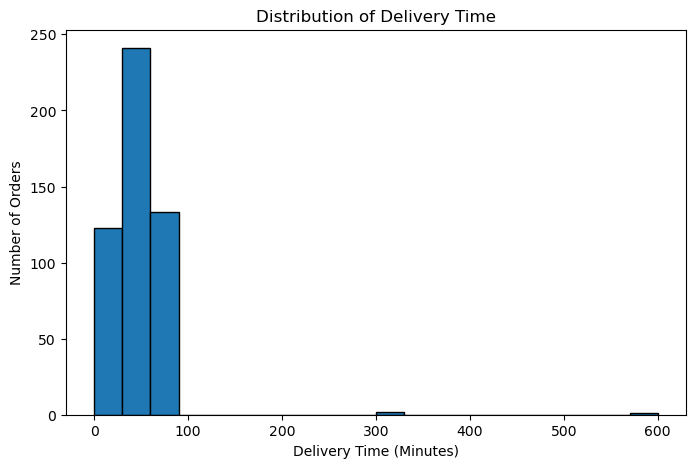

In [44]:
plt.figure(figsize=(8,5))
plt.hist(order1['Delivery_Time_Min'].dropna(),bins=20,edgecolor='black')
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")
plt.show()

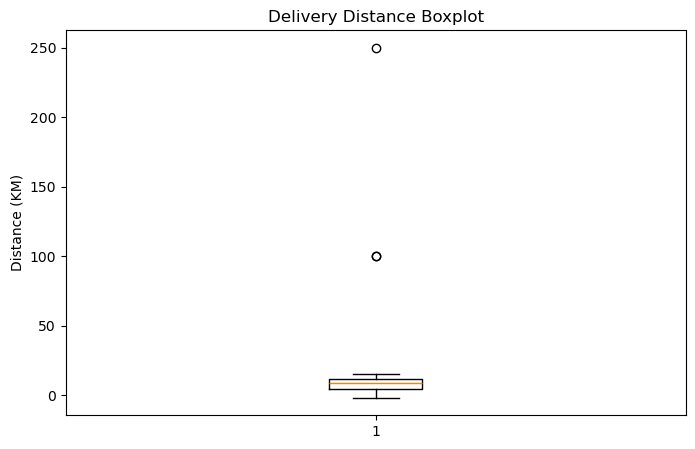

In [45]:
plt.figure(figsize=(8,5))
plt.boxplot(order1['Delivery_Distance_KM'].dropna())
plt.title("Delivery Distance Boxplot")
plt.ylabel("Distance (KM)")
plt.show()

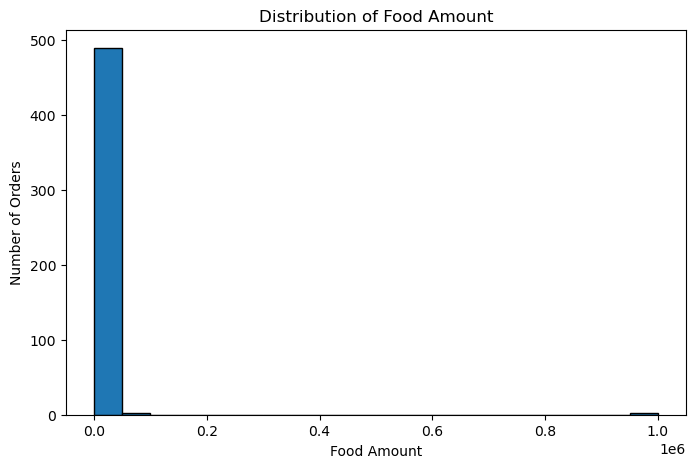

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(
    order1["Food_Amount"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Food Amount")
plt.xlabel("Food Amount")
plt.ylabel("Number of Orders")
plt.show()

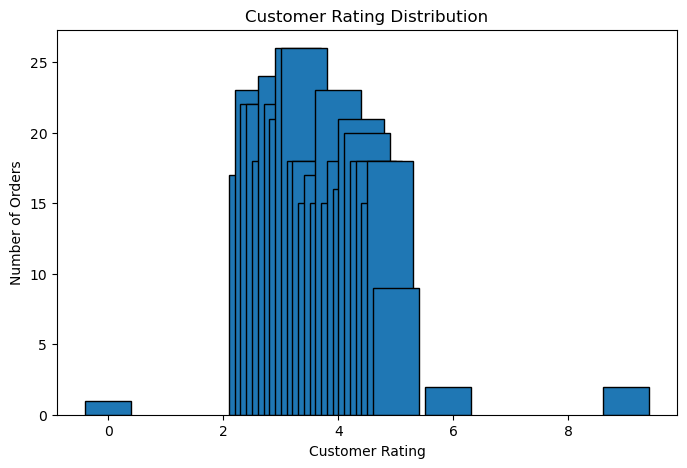

In [51]:
rating_count=order1['Customer_Rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(rating_count.index,rating_count.values,edgecolor='black')
plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")
plt.show()

In [54]:
customer1.to_csv("clean_customer1.csv",index='false')
order1.to_csv("clean_order1.csv",index='false')
restaurants1.to_csv("clean_restaurants1.csv",index='false')